# COMP 432 Project

Team members: Sean Meath 40175293, 

Imports:

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import sklearn
import os
import cv2

from torchvision import datasets
from torch.utils.data import Dataset
from torchvision.transforms import ToTensor
from torch.utils.data import DataLoader
from PIL import Image
from pathlib import Path
from torch.autograd import Variable

A:\ProgrammingStuff\Other\Anaconda3\lib\site-packages\torchvision\io\image.py:11: UserWarning: Failed to load image Python extension: Could not find module 'A:\ProgrammingStuff\Other\Anaconda3\Lib\site-packages\torchvision\image.pyd' (or one of its dependencies). Try using the full path with constructor syntax.
  warn(f"Failed to load image Python extension: {e}")


Temporary Use of EMNIST Dataset:

In [2]:
train_data = datasets.EMNIST(
    root = 'data',
    split = 'balanced',
    train = True,                         
    transform = ToTensor(), 
    download = True,            
)
test_data = datasets.EMNIST(
    root = 'data', 
    split = 'balanced',
    train = False, 
    transform = ToTensor()
)

loaders = {
    'train' : torch.utils.data.DataLoader(train_data, 
                                          batch_size=100, 
                                          shuffle=True, 
                                          num_workers=1),
    
    'test'  : torch.utils.data.DataLoader(test_data, 
                                          batch_size=100, 
                                          shuffle=True, 
                                          num_workers=1),
}

EMNIST Dataset Visualization:

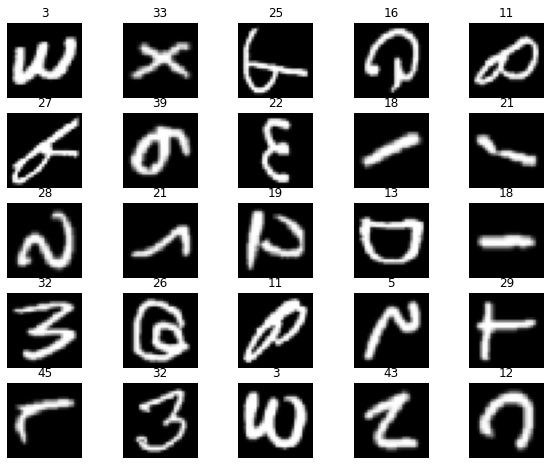

In [3]:
figure = plt.figure(figsize=(10, 8))
cols, rows = 5, 5
for i in range(1, cols * rows + 1):
    sample_idx = torch.randint(len(train_data), size=(1,)).item()
    img, label = train_data[sample_idx]
    figure.add_subplot(rows, cols, i)
    plt.title(label)
    plt.axis("off")
    plt.imshow(img.squeeze(), cmap="gray")
plt.show()

Dataset Creation: https://stackoverflow.com/questions/66711654/converting-image-into-mnist-format
                  https://github.com/gskielian/JPG-PNG-to-MNIST-NN-Format/blob/master/convert-images-to-mnist-format.py
                  https://www.youtube.com/watch?v=iwoLAj-SZ80

In [4]:
#Get Image Directory
cwd = Path.cwd()
imgdir = os.path.join(cwd, 'img')

customImages = torch.zeros(len(os.listdir(imgdir)), 1, 28, 28)
customLabels = torch.zeros(len(os.listdir(imgdir)))

counter = 0

for filename in os.listdir(imgdir):
    filepath = os.path.join(imgdir, filename)
    img = cv2.imread(filepath, cv2.IMREAD_GRAYSCALE)
    img_resized = cv2.resize(img, (28, 28), interpolation=cv2.INTER_LINEAR)
    img_resized = cv2.bitwise_not(img_resized)
    img_resized = np.copy(img_resized).reshape(1,28,28)
    img_final = torch.tensor(img_resized, dtype=torch.float32)
    
    img_label = torch.tensor(0)
    
    customImages[counter] = img_final
    customLabels[counter] = img_label
    counter += 1
        
print(customImages.shape)
print(customImages[0].shape)

customData = (customImages, customLabels)

torch.Size([2, 1, 28, 28])
torch.Size([1, 28, 28])


Custom Dataset Visualization:

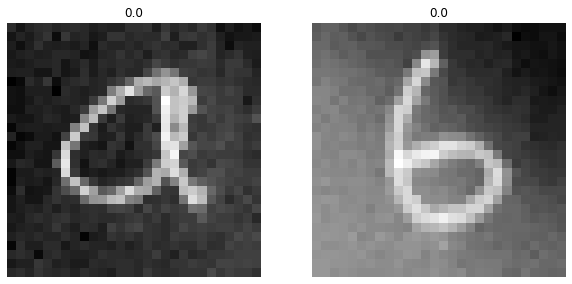

In [5]:
figure = plt.figure(figsize=(10, 8))
cols, rows = 2, 1
for i in range(1, cols * rows + 1):
    img, label = customData[0][i-1], customData[1][i-1]
    figure.add_subplot(rows, cols, i)
    plt.title(label.item())
    plt.axis("off")
    plt.imshow(img.squeeze(), cmap="gray")
plt.show()

Logistic Regression: https://jovian.ai/fonzi956/03-logistic-regression-emnist

not working

In [6]:
#input_size = 28*28
#num_classes = 47

#class LinearModel(nn.Module):
#    def __init__(self):
#        super().__init__()
#        self.linear = nn.Linear(input_size, num_classes)
#        
#    def forward(self, xb):
#        xb = xb.reshape(-1, 784)
#        out = self.linear(xb)
#        return out
    
#linear = LinearModel()
#loss_func = F.cross_entropy
#optimizer = optim.Adam(model.parameters(), lr = 0.01)

Logistic Regression Training:

In [7]:
#num_epochs = 10

#def train(num_epochs, linear, loaders):
#    linear.train()
        
    # Train the model
#    total_step = len(loaders['train'])
        
#    for epoch in range(num_epochs):
#        for i, (images, labels) in enumerate(loaders['train']):
            
            # gives batch data, normalize x when iterate train_loader
#            b_x = Variable(images)   # batch x
#            b_y = Variable(labels)   # batch y
#            output = linear(b_x)[0]
#            loss = loss_func(output, b_y)
            
            # clear gradients for this training step   
#            optimizer.zero_grad()           
            
            # backpropagation, compute gradients 
#            loss.backward()                # apply gradients             
#            optimizer.step()                
            
#            if (i+1) % 100 == 0:
#                print ('Epoch [{}/{}], Step [{}/{}], Loss: {:.4f}' 
#                       .format(epoch + 1, num_epochs, i + 1, total_step, loss.item()))
                
#train(num_epochs, linear, loaders)

Logistic Regression 2: Keep until other works

In [8]:
#from sklearn.linear_model import LogisticRegression

#model = LogisticRegression(max_iter=1000)

#model.fit(X_train_em_re, y_train_em)

In [9]:
#print(f"{((1 - model.score(X_train_em_re, y_train_em)) * 100):.2f}% training error")
#print(f"{((1 - model.score(X_test_em_re, y_test_em)) * 100):.2f}% testing error")

CNN Definition: https://medium.com/@nutanbhogendrasharma/pytorch-convolutional-neural-network-with-mnist-dataset-4e8a4265e118

to be modified but it works

In [10]:
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        self.conv1 = nn.Sequential(          
            nn.Conv2d(
                in_channels=1,              
                out_channels=16,            
                kernel_size=5,              
                stride=1,                   
                padding=2,                  
            ),                              
            nn.ReLU(),                      
            nn.MaxPool2d(kernel_size=2),    
        )
        self.conv2 = nn.Sequential(         
            nn.Conv2d(16, 32, 5, 1, 2),     
            nn.ReLU(),                      
            nn.MaxPool2d(2),                
        )        # fully connected layer, output 47 classes
        self.out = nn.Linear(32 * 7 * 7, 47)
        
    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)        # flatten the output of conv2 to (batch_size, 32 * 7 * 7)
        x = x.view(x.size(0), -1)       
        output = self.out(x)
        return output, x    # return x for visualization

cnn = CNN()
loss_func = nn.CrossEntropyLoss()
optimizer = optim.Adam(cnn.parameters(), lr = 0.01)

CNN Training:

In [ ]:
num_epochs = 3

def train(num_epochs, cnn, loaders):
    cnn.train()
        
    # Train the model
    total_step = len(loaders['train'])
        
    for epoch in range(num_epochs):
        for i, (images, labels) in enumerate(loaders['train']):
            
            # gives batch data, normalize x when iterate train_loader
            b_x = Variable(images)   # batch x
            b_y = Variable(labels)   # batch y
            output = cnn(b_x)[0]               
            loss = loss_func(output, b_y)
            
            # clear gradients for this training step   
            optimizer.zero_grad()           
            
            # backpropagation, compute gradients 
            loss.backward()                # apply gradients             
            optimizer.step()                
            
            if (i+1) % 100 == 0:
                print ('Epoch [{}/{}], Step [{}/{}], Loss: {:.4f}' 
                       .format(epoch + 1, num_epochs, i + 1, total_step, loss.item()))
                
train(num_epochs, cnn, loaders) 

Epoch [1/3], Step [100/1128], Loss: 0.9661
Epoch [1/3], Step [200/1128], Loss: 0.6636
Epoch [1/3], Step [300/1128], Loss: 0.5127
Epoch [1/3], Step [400/1128], Loss: 0.6359
Epoch [1/3], Step [500/1128], Loss: 0.6062
Epoch [1/3], Step [600/1128], Loss: 0.5635
Epoch [1/3], Step [700/1128], Loss: 0.8496
Epoch [1/3], Step [800/1128], Loss: 0.6100
Epoch [1/3], Step [900/1128], Loss: 0.8361
Epoch [1/3], Step [1000/1128], Loss: 0.5563
Epoch [1/3], Step [1100/1128], Loss: 0.4292
Epoch [2/3], Step [100/1128], Loss: 0.4634
Epoch [2/3], Step [200/1128], Loss: 0.4992
Epoch [2/3], Step [300/1128], Loss: 0.3918
Epoch [2/3], Step [400/1128], Loss: 0.6948
Epoch [2/3], Step [500/1128], Loss: 0.4925
Epoch [2/3], Step [600/1128], Loss: 0.3625
Epoch [2/3], Step [700/1128], Loss: 0.5514
Epoch [2/3], Step [800/1128], Loss: 0.5980
Epoch [2/3], Step [900/1128], Loss: 0.5876
Epoch [2/3], Step [1000/1128], Loss: 0.4805
Epoch [2/3], Step [1100/1128], Loss: 0.4587
Epoch [3/3], Step [100/1128], Loss: 0.7653
Epoch [

Training

In [ ]:
#num_epochs = 3
#train(num_epochs, cnn, loaders)

In [ ]:
imgs, lbls = customData
test_output, last_layer = cnn(imgs)
pred_y = torch.max(test_output, 1)[1].data.numpy().squeeze()
print(f'Prediction class: {pred_y}')

In [ ]:
sample = next(iter(loaders['test']))
imgs, lbls = sample
actual_number = lbls[:10].numpy()

print(imgs[:10].shape)
print(imgs[0].shape)

test_output, last_layer = cnn(imgs[:10])
pred_y = torch.max(test_output, 1)[1].data.numpy().squeeze()
print(f'Prediction number: {pred_y}')
print(f'Actual number: {actual_number}')

In [ ]:
imgs, lbls = customData
print(lbls)
actual_number = lbls[:10].numpy()

print(imgs[:10].shape)
print(imgs[0].shape)

test_output, last_layer = cnn(imgs[:10])
pred_y = torch.max(test_output, 1)[1].data.numpy().squeeze()
print(f'Prediction number: {pred_y}')
print(f'Actual number: {actual_number}')